# Nibabel Basics Notebook
### *Learning how to load and view MRI scans*

## Import Libraries
We need nibabel for MRI files and matplotlib for plotting.

In [66]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

## Upload an MRI File (.nii.gz)
Upload any NIfTI file.

In [67]:
from nibabel.testing import data_path

## Load MRI File
Nibabel loads the 3D MRI volume as a NumPy array.

In [68]:
# file_path = list(uploaded.keys())[0]
file_name = os.path.join(data_path, 'example4d.nii.gz')
mri = nib.load(file_name).get_fdata()
print('MRI Shape:', mri.shape)

MRI Shape: (128, 96, 24, 2)


## Visualize a Middle Slice
MRI is 3D. We view one slice at a time.

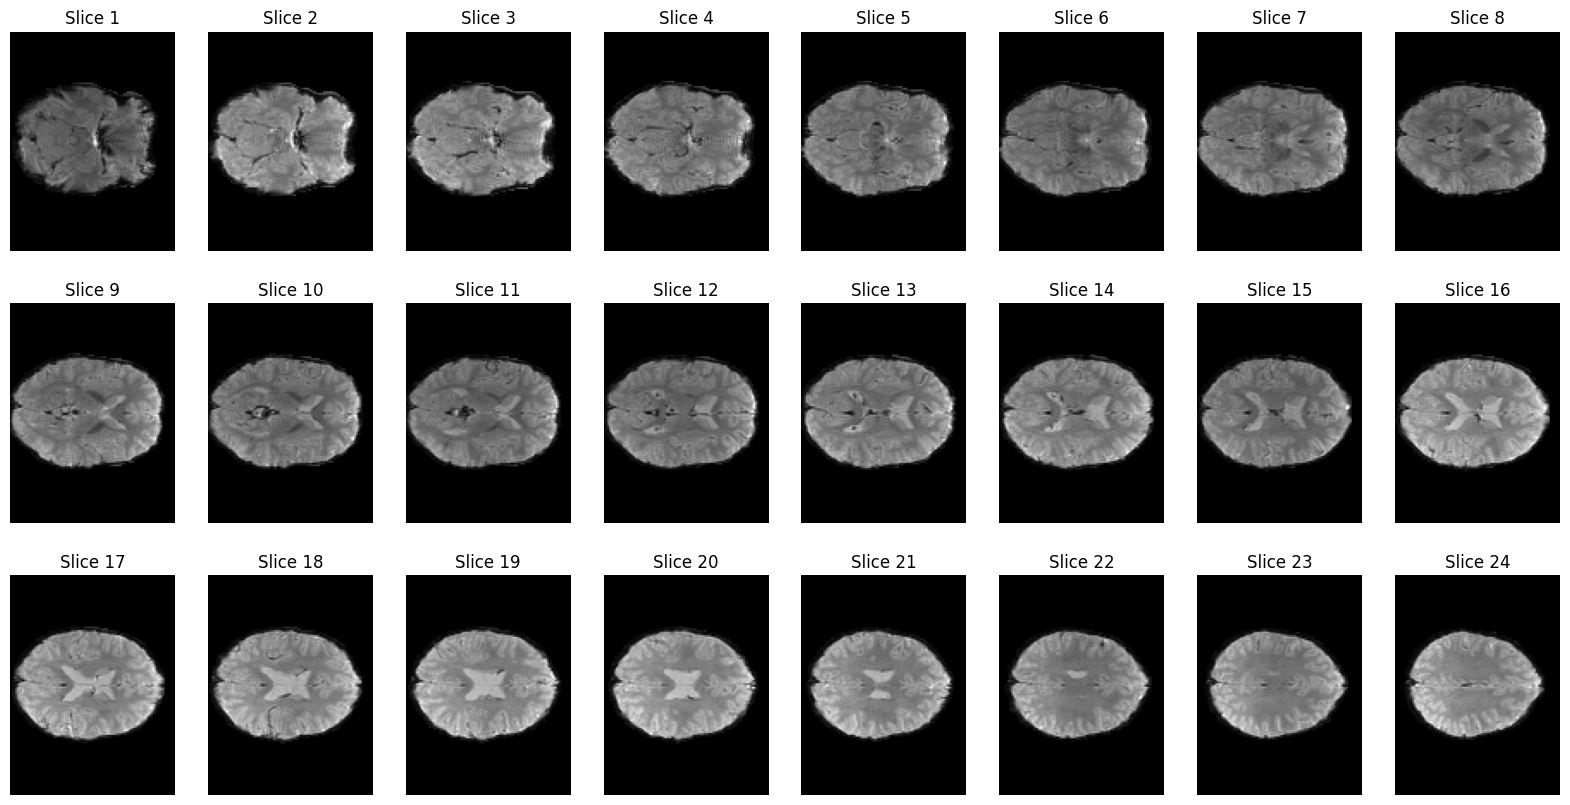

In [69]:
slice_index = mri.shape[2] // 2

plt.figure(figsize=(20, 10))

for i in range(mri.shape[2]):
    plt.subplot(3, 8, i+1)
    plt.imshow(mri[:, :, i,0], cmap='gray')
    plt.title(f'Slice {i+1}')
    plt.axis('off')

## Extract All Slices
Convert 3D MRI into 2D slices.

In [70]:
slices = [mri[:, :, i] for i in range(mri.shape[2])]
len(slices)

24

## Normalize a Slice
Normalization improves contrast.

(np.float64(-0.5), np.float64(95.5), np.float64(127.5), np.float64(-0.5))

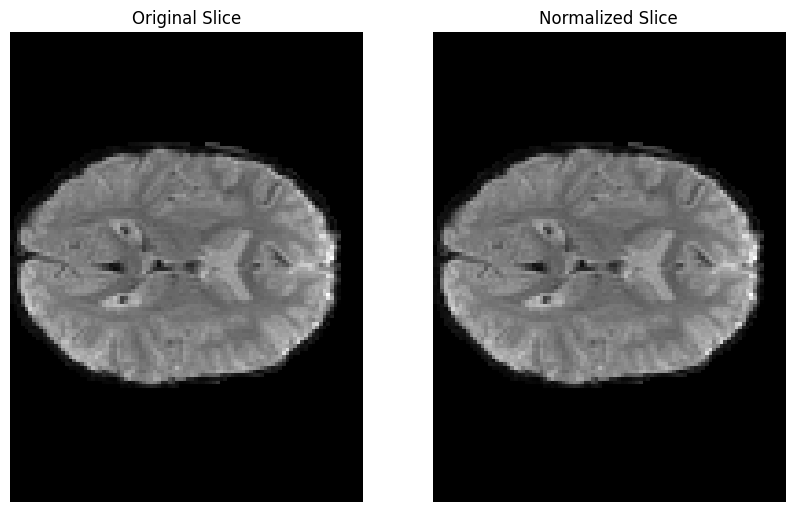

In [71]:
plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(mri[:, :, slice_index, 0], cmap='gray')
plt.title('Original Slice')
plt.axis('off')

plt.subplot(1, 2, 2)
norm_slice = (mri[:, :, slice_index, 0] - np.min(mri)) / (np.max(mri) - np.min(mri))
plt.imshow(norm_slice, cmap='gray')
plt.title('Normalized Slice')
plt.axis('off')

## Resize Slice (Used in ML Preprocessing)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

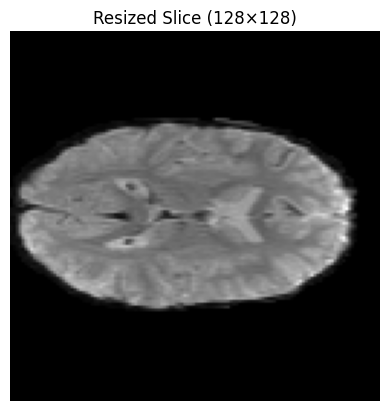

In [72]:
import tensorflow as tf
resized = tf.image.resize(norm_slice[..., None], (128, 128))
plt.imshow(resized.numpy().squeeze(), cmap='gray')
plt.title('Resized Slice (128×128)')
plt.axis('off')

### **Exercise 1** : Load **another** MRI file and visualize 5 slices.

MRI Shape: (240, 240, 155)


(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

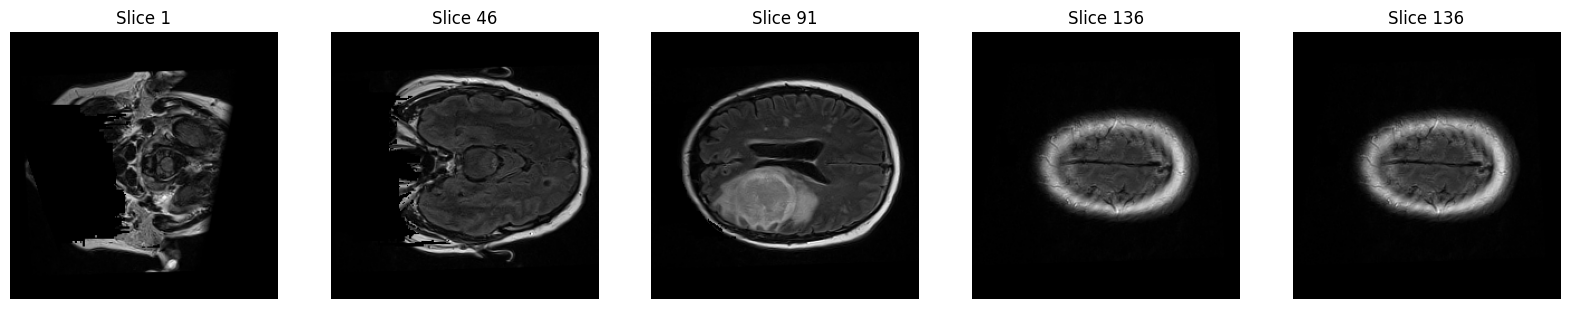

In [73]:
mri = nib.load('flair.nii.gz').get_fdata()
print('MRI Shape:', mri.shape)

plt.figure(figsize=(20,20))

i=0
plt.subplot(1,5,1)
plt.imshow(mri[:,:,i],cmap='gray')
plt.title(f"Slice {i+1}")
plt.axis('off')

plt.subplot(1,5,2)
plt.imshow(mri[:,:,i+45],cmap='gray')
plt.title(f"Slice {i+1+45}")
plt.axis('off')

plt.subplot(1,5,3)
plt.imshow(mri[:,:,i+90],cmap='gray')
plt.title(f"Slice {i+1+90}")
plt.axis('off')

plt.subplot(1,5,4)
plt.imshow(mri[:,:,i+135],cmap='gray')
plt.title(f"Slice {i+1+135}")
plt.axis('off')

plt.subplot(1,5,5)
plt.imshow(mri[:,:,i+135],cmap='gray')
plt.title(f"Slice {i+1+135}")
plt.axis('off')

### **Exercise 2** : Write a function `plot_slices(volume, indices)` to plot given slice numbers.

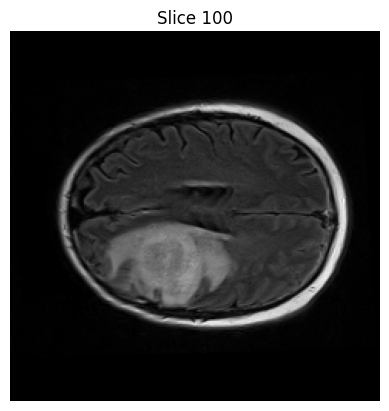

In [74]:
def plot_slices(volume, indices):
    plt.imshow(volume[:, :, indices-1], cmap='gray')
    plt.title(f'Slice {indices}')
    plt.axis('off')

plot_slices(mri,100)

### **Exercise 3** : Create a function to normalize **all** slices and return the new array.

In [75]:
def resize(volume):
    norm_slice = (volume[:, :, :] - np.min(volume)) / (np.max(volume) - np.min(volume))
    return norm_slice